# Datset A

In [1]:
from sklearn.datasets import make_blobs
import numpy as np


X, y_true = make_blobs (
    n_samples=400,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

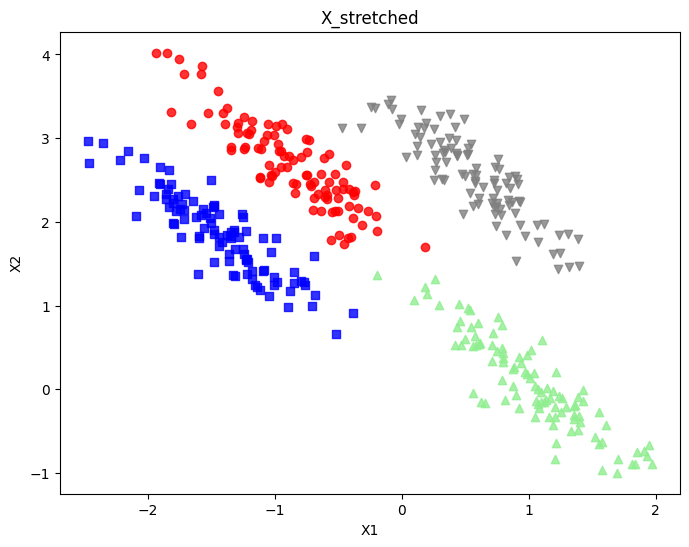

In [2]:
import matplotlib.pyplot as plt


def show_scatter(X, y, title=None):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    plt.figure(figsize=(8, 6))
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            X[y == cl, 0],
            X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f'Class {cl}'
        )
    plt.title(title)
    if title:
        plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

show_scatter(X_stretched, y_true, title="X_stretched")

In [3]:
import seaborn as sns
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score


def get_classifier_score(X, y, classifier):
    """
    Розрахунок та виведення значень критеріїв якості.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
    """

    y_pred = classifier.predict(X)

    class_names = [f"Class {i}" for i in np.unique(y).astype(int)]

    # Вивід значення критеріїв якості
    print(metrics.classification_report(y, y_pred, target_names=class_names))

    # Матриця неточностей
    conf_matrix = metrics.confusion_matrix(y, y_pred)
    plt.figure(figsize =(6, 6))
    sns.heatmap(
        data=conf_matrix,
        xticklabels=class_names,
        yticklabels=class_names,
        annot=True,
        fmt="d",
        square=True,
        cmap="coolwarm",
        vmax=20
    )
    plt.ylabel("True class")
    plt.xlabel("Predicted class")
    plt.show()

In [4]:
from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, classifier_name, resolution=0.02):
    """
    Візуалізація меж класифікації.
    Параметри:
        X                - ознаки
        y                - справжні мітки
        classifier       - навчена модель
        classifier_name  - назва моделі,
                     яка відображається в заголовку графіка
        resolution - крок сітки для побудови областей
    """

    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Створюємо сітку точок для візуалізації меж
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Створюємо сітку координат
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    # Прогноз для кожної точки сітки
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    # Малюємо графік
    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.title(classifier_name)
    plt.xlabel("X1")
    plt.ylabel("X2")
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl,0],
            y=X[y == cl,1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black"
        )

    plt.show()

In [5]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_stretched, y_true, test_size=0.25, random_state=0
)

In [6]:
from sklearn.neural_network import MLPClassifier
import warnings


warnings.filterwarnings('ignore', module='sklearn')

# Дефолтні значення
# (тільки max_iter=500, бо з adam оптимізатором
# погано сходиться на дефолних значеннях)
clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=500,
    random_state=42
)

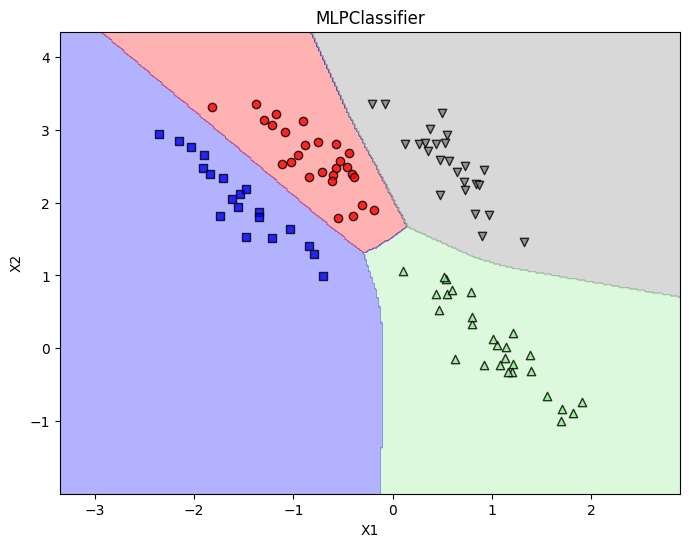

In [7]:
clf.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, clf, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99        73
     Class 1       1.00      1.00      1.00        80
     Class 2       1.00      1.00      1.00        72
     Class 3       0.99      0.99      0.99        75

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



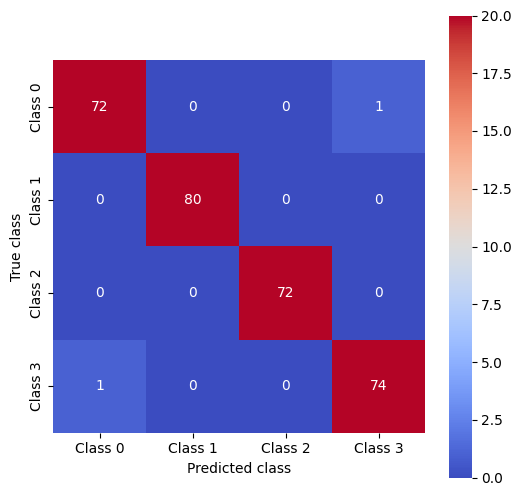

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        27
     Class 1       1.00      1.00      1.00        20
     Class 2       1.00      1.00      1.00        28
     Class 3       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



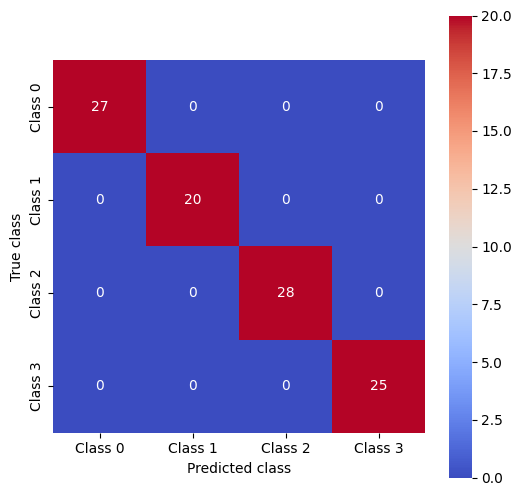

In [8]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, clf)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, clf)

In [9]:
# Overfitting
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

-0.0067


MLP з дефолтними параметрами (один скритий шар з 100 нейронами) достатньо для класифікації нашого датасету.

## Динамічне додавання нейронів до скритого шару

In [14]:
threshold = 0.95
neurons_num = [1, 5, 10, 50, 100]
tries = 3
min_neurons_num = neurons_num[-1]

for i in range(tries):
  print(f"Iteration: {i}")

  for n in neurons_num:
    clf_dynamic = MLPClassifier(hidden_layer_sizes=(n,),
                        warm_start=True,
                        max_iter=200)

    clf_dynamic.fit(X_train, y_train)
    model_score = clf_dynamic.score(X_test, y_test)

    print(f"\tScore with {n} neurons: {model_score:.4f}")

    if model_score >= threshold:
      curr_neurons = n
      break

    curr_neurons = n

  if curr_neurons < min_neurons_num:
    min_neurons_num = curr_neurons

print(f"\nMinimal number of neurons ~ {min_neurons_num}")

Score with 1 neurons: 0.6000
Score with 5 neurons: 0.5600
Score with 10 neurons: 0.9000
Score with 50 neurons: 1.0000
Score with 1 neurons: 0.3900
Score with 5 neurons: 0.9600
Score with 1 neurons: 0.2700
Score with 5 neurons: 0.6700
Score with 10 neurons: 0.8900
Score with 50 neurons: 1.0000

Minimal number of neurons ~ 5


5 нейронів в одношаровій моделі буде достатньо для задовільного розв'язання задачі з датасетом А.

## Знаходження оптимального варіанту архітектури

In [15]:
from sklearn.model_selection import GridSearchCV
import warnings


warnings.filterwarnings('ignore', module='sklearn')

param_grid_mlp = {
    "hidden_layer_sizes": [(10,), (50,), (100,),
                           (10, 5), (64, 32), (100, 50), (128, 64)],
    "solver": ["adam", "lbfgs", "sgd"],
}

grid_mlp = GridSearchCV(clf, param_grid_mlp, cv=5, verbose=1)
grid_mlp.fit(X_train, y_train)

print(f"Best params:    {grid_mlp.best_params_}")
print(f"Train accuracy: {grid_mlp.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mlp.best_estimator_.predict(X_test))}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params:    {'hidden_layer_sizes': (128, 64), 'solver': 'adam'}
Train accuracy: 0.9966666666666667
Test accuracy:  1.0


In [16]:
# Overfitting
train_acc = accuracy_score(y_train, grid_mlp.predict(X_train))
test_acc = accuracy_score(y_test, grid_mlp.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0000


# Datset B

In [17]:
np.random.seed(0)
X = np.random.randn(300, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

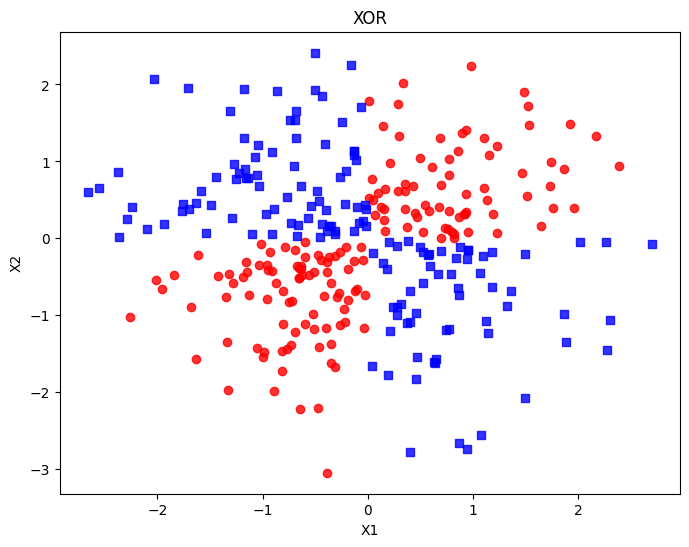

In [18]:
show_scatter(X, y, title="XOR")

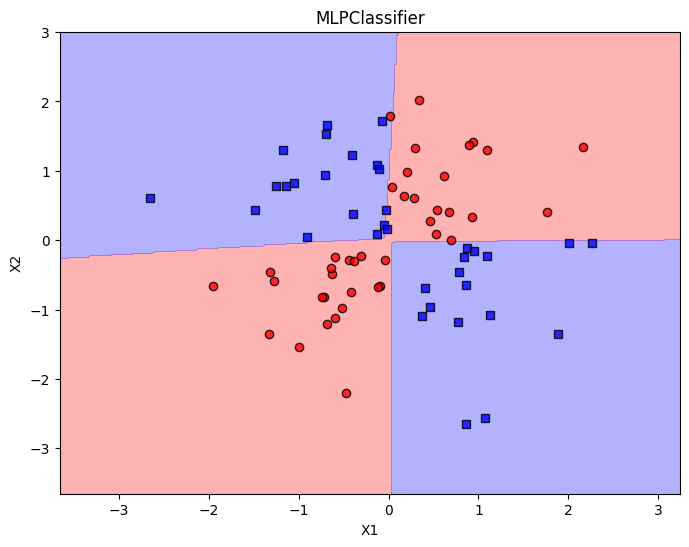

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Дефолтні значення
# (тільки max_iter=500, бо з adam оптимізатором
# погано сходиться на дефолних значеннях)
clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=500,
    random_state=42
)

clf.fit(X_train, y_train)
plot_decision_regions(X_test, y_test, clf, classifier_name="MLPClassifier")

Evaluation metrics for train set:
              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00       118
     Class 1       1.00      0.99      1.00       107

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



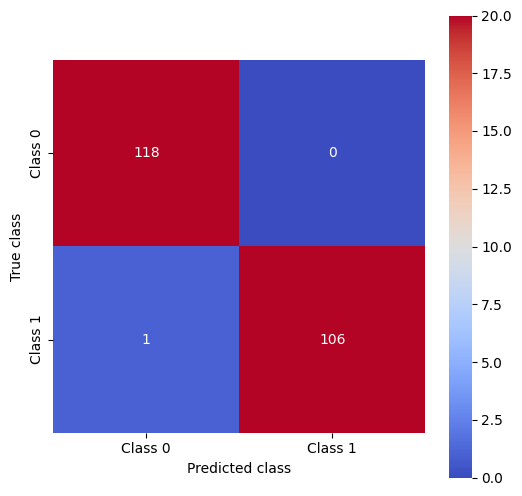

Evaluation metrics for test set:
              precision    recall  f1-score   support

     Class 0       0.97      0.97      0.97        40
     Class 1       0.97      0.97      0.97        35

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



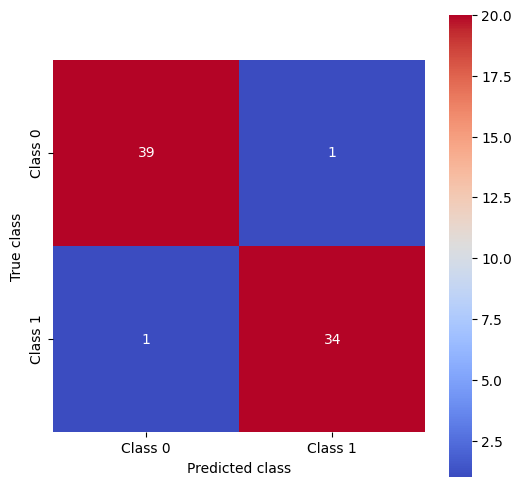

In [20]:
print("Evaluation metrics for train set:")
get_classifier_score(X_train, y_train, clf)

print("Evaluation metrics for test set:")
get_classifier_score(X_test, y_test, clf)

In [21]:
# Overfitting
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0222


## Динамічне додавання нейронів до скритого шару

In [25]:
threshold = 0.95
neurons_num = [1, 5, 10, 50, 100]
tries = 3
min_neurons_num = neurons_num[-1]

for i in range(tries):
  print(f"Iteration: {i}")

  for n in neurons_num:
    clf_dynamic = MLPClassifier(hidden_layer_sizes=(n,),
                        warm_start=True,
                        max_iter=200)

    clf_dynamic.fit(X_train, y_train)
    model_score = clf_dynamic.score(X_test, y_test)

    print(f"\tScore with {n} neurons: {model_score:.4f}")

    if model_score >= threshold:
      curr_neurons = n
      break

    curr_neurons = n

  if curr_neurons < min_neurons_num:
    min_neurons_num = curr_neurons

print(f"\nMinimal number of neurons ~ {min_neurons_num}")

Iteration: 0
	Score with 1 neurons: 0.6667
	Score with 5 neurons: 0.8400
	Score with 10 neurons: 0.8400
	Score with 50 neurons: 0.9333
	Score with 100 neurons: 0.9733
Iteration: 1
	Score with 1 neurons: 0.4667
	Score with 5 neurons: 0.6667
	Score with 10 neurons: 0.8267
	Score with 50 neurons: 0.9333
	Score with 100 neurons: 0.9733
Iteration: 2
	Score with 1 neurons: 0.4800
	Score with 5 neurons: 0.8000
	Score with 10 neurons: 0.8933
	Score with 50 neurons: 0.9467
	Score with 100 neurons: 0.9600

Minimal number of neurons ~ 100


100 нейронів в одношаровій моделі буде достатньо для задовільного розв'язання задачі з датасетом B.

## Знаходження оптимального варіанту архітектури

In [28]:
from sklearn.model_selection import GridSearchCV
import warnings


warnings.filterwarnings('ignore', module='sklearn')

param_grid_mlp = {
    "hidden_layer_sizes": [(10,), (50,), (100,),
                           (10, 5), (64, 32), (100, 50), (128, 64)],
    "solver": ["adam", "lbfgs", "sgd"],
}

grid_mlp = GridSearchCV(clf, param_grid_mlp, cv=5, verbose=1)
grid_mlp.fit(X_train, y_train)

print(f"Best params:    {grid_mlp.best_params_}")
print(f"Train accuracy: {grid_mlp.best_score_}")
print(f"Test accuracy:  {accuracy_score(y_test, grid_mlp.best_estimator_.predict(X_test))}")

Fitting 5 folds for each of 21 candidates, totalling 105 fits
Best params:    {'hidden_layer_sizes': (50,), 'solver': 'lbfgs'}
Train accuracy: 0.9911111111111112
Test accuracy:  0.9866666666666667


In [30]:
# Overfitting
train_acc = accuracy_score(y_train, grid_mlp.predict(X_train))
test_acc = accuracy_score(y_test, grid_mlp.predict(X_test))
print(f"{(train_acc - test_acc):.4f}")

0.0133


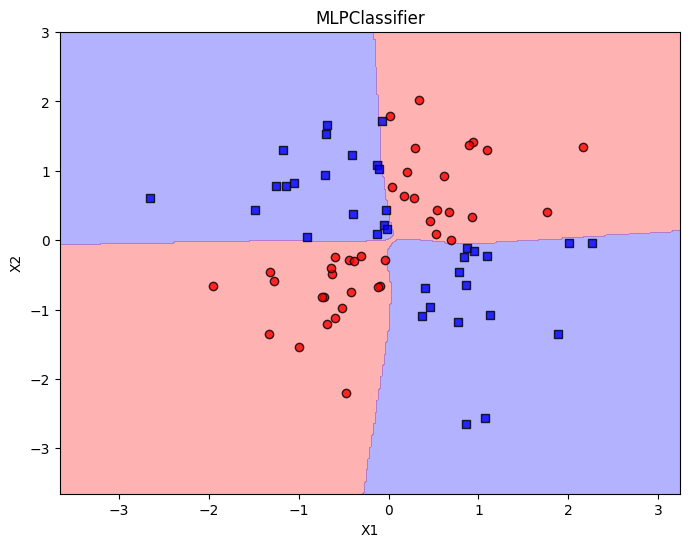

In [29]:
plot_decision_regions(X_test, y_test, grid_mlp, classifier_name="MLPClassifier")

Виглядає якось перенавчено, датасет замалий, щоб підтвердити це.